<a href="https://colab.research.google.com/github/Afif-Ghifari/PCVK_2025/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>MODUL 7 – Filter Spasial Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection</h1>
<hr>
<h2>Percobaan Praktikum</h2>

<b>Nama : Muhammad Afif Al Ghifari</b><br>
<b>Kelas: TI-3H</b><br>
<b>NIM  : 2341720168</b>

<h2>PRAKTIKUM FILTER</h2>


1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa  menggunakan library atau metode konvolusi dari OpenCV.
2. Berikut merupakan langkah-langkah yang dapat dilakukan:
- a. Buat notebook baru pada google colab, dan beri nama Week7.ipynb. Simpan Salinan pada akun github seperti pada modul sebelumnya.
- b. Akses file yang terdapat pada drive dan import beberapa library yang



In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Mounted at /content/drive


- c. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi. Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan padding.

In [10]:
def convolution2d(image, kernel, stride=1, padding=0):
    img_h, img_w = len(image), len(image[0])
    k_h, k_w = len(kernel), len(kernel[0])

    # Padding citra
    padded_image = [[0 for _ in range(img_w + 2 * padding)] for _ in range(img_h + 2 * padding)]
    for i in range(img_h):
        for j in range(img_w):
            padded_image[i + padding][j + padding] = image[i][j]

    # Ukuran output
    out_h = (img_h - k_h + 2 * padding) // stride + 1
    out_w = (img_w - k_w + 2 * padding) // stride + 1
    output = [[0 for _ in range(out_w)] for _ in range(out_h)]

    # Konvolusi
    for y in range(0, out_h):
        for x in range(0, out_w):
            val = 0
            for i in range(k_h):
                for j in range(k_w):
                    val += kernel[i][j] * padded_image[y * stride + i][x * stride + j]
            output[y][x] = val

    return output

- d. Load citra yang akan diproses dan ubah menjadi citra keabuan


In [26]:
img = cv.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


- e. Tentukan kernel yang akan digunakan

In [7]:
kernel_sharpen = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
    ])

- f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:

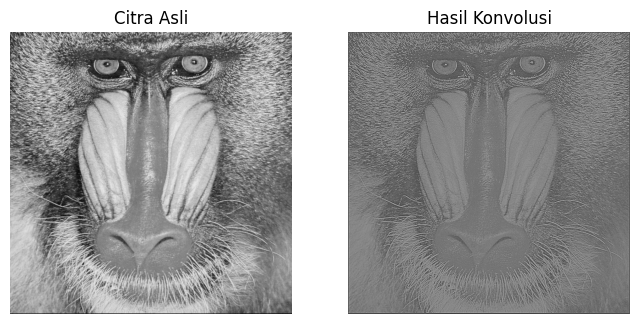

In [32]:
result = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Plot citra asli dan hasil konvolusi
def showImg(img, title):
  fig, axes = plt.subplots(1, 2, figsize=(8,4))

  axes[0].imshow(img_gray, cmap='gray')
  axes[0].set_title("Citra Asli")
  axes[0].axis("off")

  axes[1].imshow(img, cmap='gray')
  axes[1].set_title(title)
  axes[1].axis("off")

  plt.show()

showImg(result, "Hasil Konvolusi")

3. Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter
berikut:

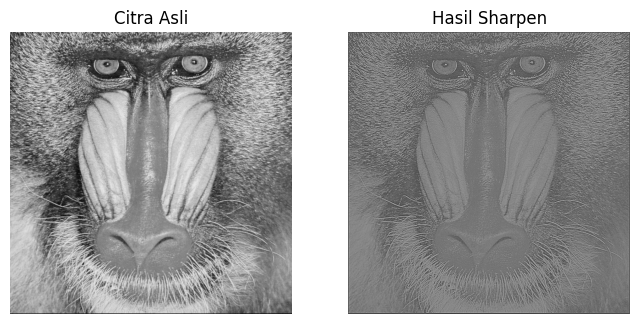

In [41]:
sharpen = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
    ])

result = convolution2d(img_gray, sharpen, 1, 2)
showImg(result, "Hasil Sharpen")

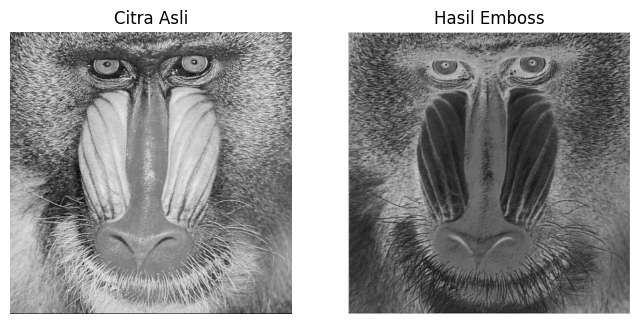

In [44]:
emboss = np.array([
    [-2,-1,0],
    [-1,-1,-1],
    [0,-1,2]
    ])

resultEmboss = convolution2d(img_gray, emboss, 1, 2)
showImg(resultEmboss, "Hasil Emboss")

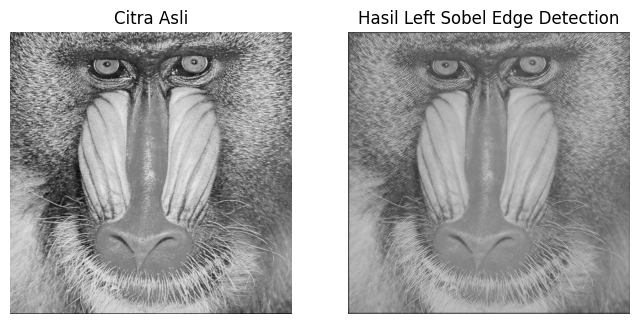

In [39]:
LeftSobelEdgeDetection = np.array([
    [1,0,1],
    [2,0,-2],
    [0,-1,2]
    ])

resultLeftSobelEdgeDetection = convolution2d(img_gray, LeftSobelEdgeDetection, 1, 2)
showImg(resultLeftSobelEdgeDetection, "Hasil Left Sobel Edge Detection")
#

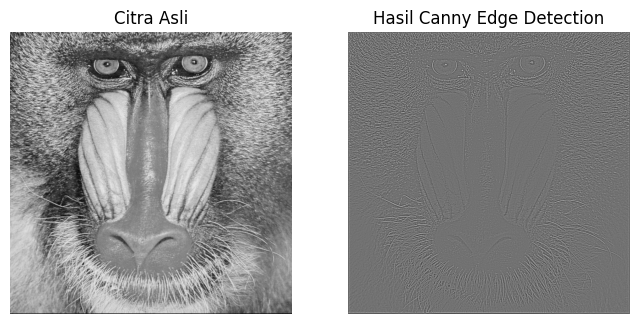

In [42]:
CannyEdgeDetection = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
    ])

resultCannyEdgeDetection = convolution2d(img_gray, CannyEdgeDetection, 1, 2)
showImg(resultCannyEdgeDetection, "Hasil Canny Edge Detection")
#

Gaussian Kernel (21x21):


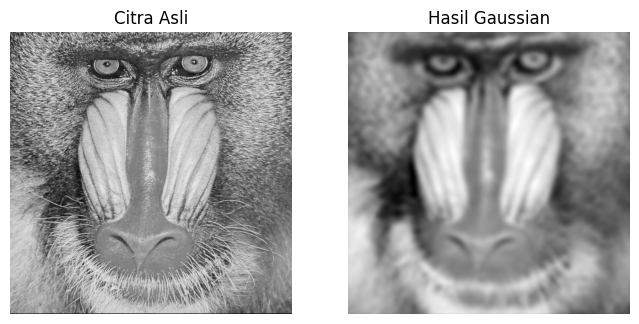

In [48]:
def gaussian_kernel(kernel_size):
    sigma = math.sqrt(kernel_size)   # bisa juga langsung tentukan sigma
    gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
    gauss_kernel = gaussian_kernel @ gaussian_kernel.T   # outer product
    return gauss_kernel

# Buat kernel Gaussian 5x5
kernel_size = 21
g_kernel = gaussian_kernel(kernel_size)

print("Gaussian Kernel ({}x{}):".format(kernel_size, kernel_size))

# Terapkan konvolusi dengan kernel Gaussian
resultGaussian = convolution2d(img_gray, g_kernel.tolist(), stride=1, padding=2)
showImg(resultGaussian, "Hasil Gaussian")

## FILTER LIBRARY DAN FILTER MODERN

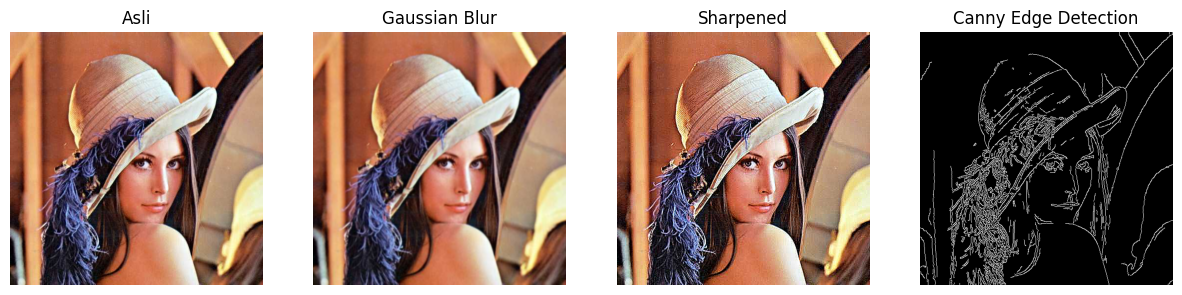

In [49]:
# Fungsi tampil berdampingan
def show_side_by_side (images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate (zip(images, titles)):
    if len(img.shape) == 2: # grayscale
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap="gray")
    else: # color
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
  plt.show()
img = cv.imread("/content/drive/MyDrive/kuliah/pcvk/asset pcvk/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur (img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5, -1], [0,-1,0]])
sharpened = cv.filter2D (img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2

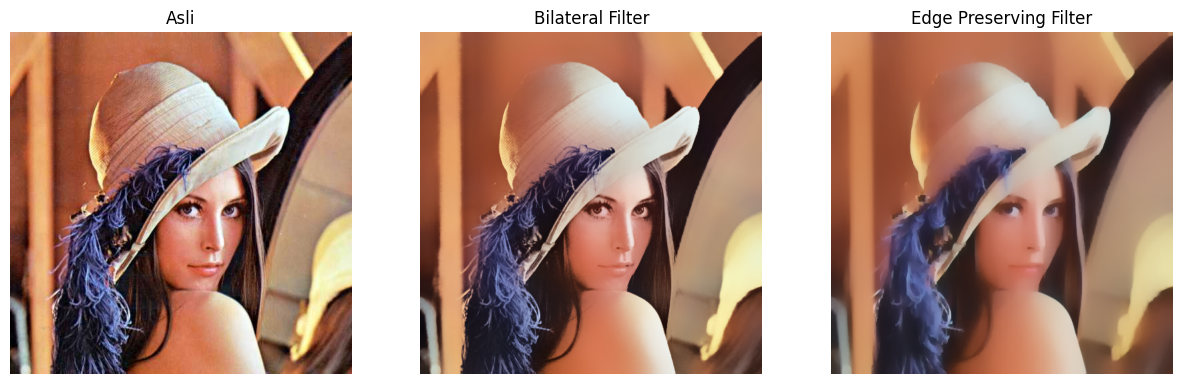

In [50]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)
# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)
show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan 3

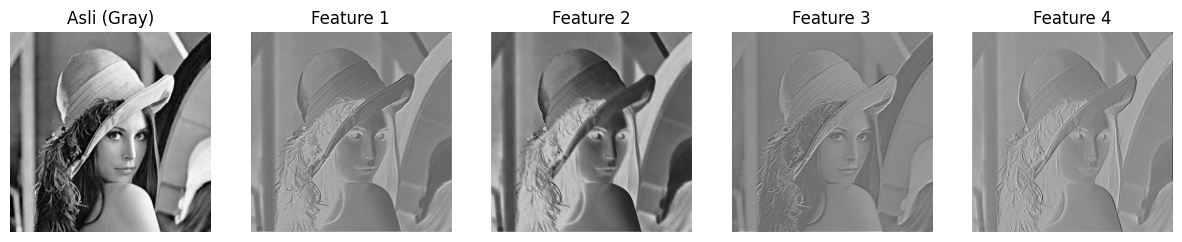

In [53]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn
# CNN sederhana
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        return self.conv1(x)

# Model
model = SimpleCNN()

# Ubah gambar grayscale ke tensor (anggap img_gray = numpy array 2D)
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Ambil feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

# Fungsi visualisasi
def show_side_by_side(images, titles):
    fig, axes = plt.subplots(1, len(images), figsize=(15,5))
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap="gray")
        ax.set_title(titles[i])
        ax.axis("off")
    plt.show()

# Tampilkan hasil
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan 4

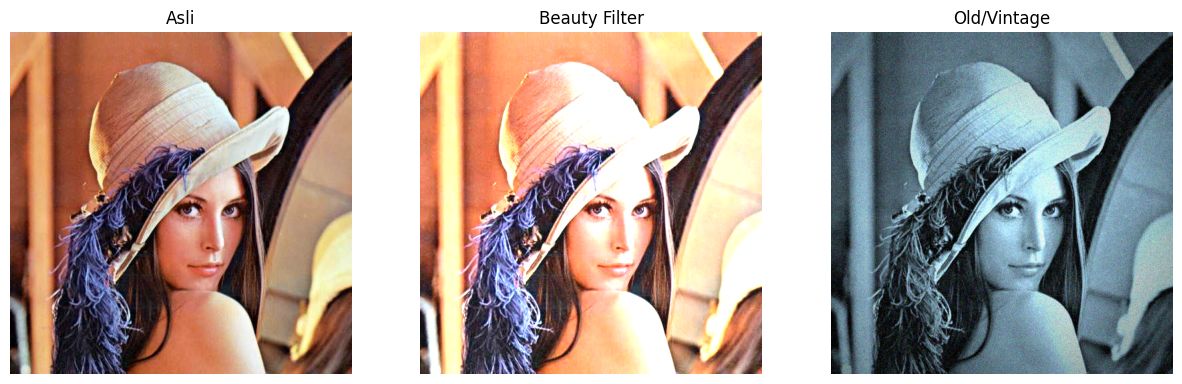

In [74]:
img = cv.imread("/content/drive/MyDrive/kuliah/pcvk/asset pcvk/lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
# ==============
# 1 Beauty Filter
# ==============
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(img, (0,0), 3)
sharpened = cv.addWeighted(img, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness dan kontras
alpha = 1.5
beta = 15
bright = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==============
# 2 Old/Vintage Filter
# ==============

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img,  bright, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage"])

Percobaan 5

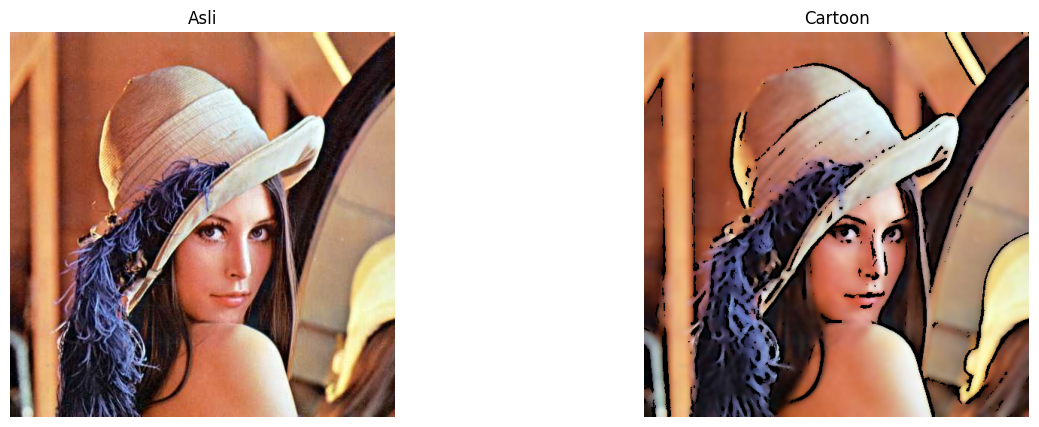

In [76]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon],
                  ["Asli", "Cartoon"])

Percobaan 6

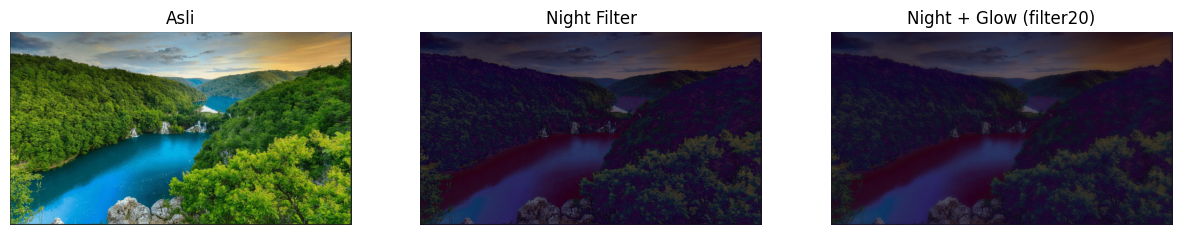

In [86]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/kuliah/pcvk/asset pcvk/jungle.png")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted (night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
["Asli", "Night Filter", "Night + Glow (filter20)"])

Percobaan 7

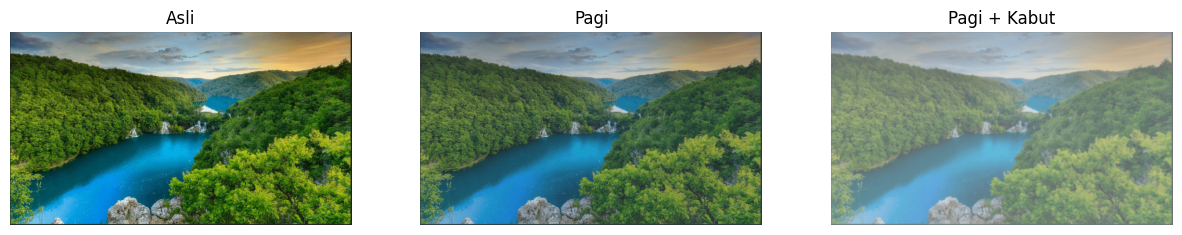

In [88]:
#Filter Suasana pagi dan Kabut
# =============================
# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])


##